# Tag 03 - Imbalanced Learning

This notebook solves the Day 3 exercises.

## Main topics

1. Imbalanced Data
2. Accuracy problem
3. Confusion Matrix
4. Precision, Recall, F1-score
5. ROC Curve and AUC
6. Threshold analysis
7. Random Oversampling
8. Random Undersampling
9. SMOTE
10. Class Weight / Cost-Sensitive Learning

This notebook is self-contained and does not require external CSV files.

## Dataset Validation
Run this cell to verify that your datasets are present and correctly formatted.

In [ ]:
# --- DATASET VALIDATION ---
import os
import pandas as pd

def validate_dataset(filepath, expected_columns=None, avoid_columns=None):
    if not os.path.exists(filepath):
        print(f'❌ ERROR: Dataset not found at {filepath}')
        return False
    try:
        df = pd.read_csv(filepath, nrows=5)
        print(f'✅ SUCCESS: Dataset found at {filepath} (Columns: {df.shape[1]})')
        if expected_columns:
            missing = [c for c in expected_columns if c not in df.columns]
            if missing:
                print(f'⚠️ WARNING: Missing expected columns: {missing}')
                return False
        if avoid_columns:
            forbidden = [c for c in avoid_columns if c in df.columns]
            if forbidden:
                print(f'❌ ERROR: Found forbidden columns {forbidden}. Wrong dataset!')
                return False
        return True
    except Exception as e:
        print(f'❌ ERROR: Could not read dataset: {e}')
        return False

print('Validation helper loaded. Call validate_dataset(path) before loading your data.')
# validate_dataset('../data/your_dataset.csv')

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
# Project paths

BASE_DIR = Path.cwd()

if BASE_DIR.name in ["exercise", "notebooks"]:
    BASE_DIR = BASE_DIR.parent

OUTPUT_DIR = BASE_DIR / "output" / "Experte"
DATA_DIR = BASE_DIR / "data"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("Base folder:", BASE_DIR)
print("Output folder:", OUTPUT_DIR)

Base folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques
Output folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte


In [3]:
def save_plot(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.show()
    print("Saved:", path)

def evaluate_classifier(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_true, y_prob)
    }

def plot_confusion_matrix(cm, title, filename):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.colorbar()
    plt.xticks([0, 1], ["Class 0", "Class 1"])
    plt.yticks([0, 1], ["Class 0", "Class 1"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    save_plot(filename)

# 1. Create an imbalanced dataset

We create a binary classification dataset with a strong imbalance:

- Class 0: majority class
- Class 1: minority class

This simulates real problems like fraud detection, cancer diagnosis, anomaly detection, or credit default prediction.

In [4]:
X, y = make_classification(
    n_samples=6000,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.95, 0.05],
    flip_y=0.01,
    random_state=42
)

print("Class distribution:", Counter(y))

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y

display(df.head())

df.to_csv(DATA_DIR / "day03_synthetic_imbalanced_data.csv", index=False)

Class distribution: Counter({0: 5671, 1: 329})


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,target
0,-0.842757,-0.976352,-0.990017,-0.263016,-0.162842,-0.007273,4.862119,-4.041875,-0.795764,-1.957475,...,-0.132368,-0.175648,0.066145,1.765940,0.469100,0.831464,0.965233,-2.393946,-0.463793,0
1,1.064747,-3.763265,0.466466,0.537529,-3.240992,-0.042708,4.452279,-8.298687,-1.196799,4.370717,...,-1.513612,0.786075,-1.154981,4.852973,0.871650,2.458961,0.503585,2.650560,-0.584144,0
2,-0.747640,-1.378285,0.814634,-1.434124,-0.451716,-0.146022,2.702514,-5.084437,0.963478,2.063147,...,-0.952263,-1.430460,1.283986,2.910250,-1.377512,1.049718,-1.714473,-1.492120,-1.076336,1
3,-0.399766,3.402277,0.671745,-4.694335,7.037845,-1.516967,3.131700,2.800182,-2.504080,-6.810352,...,1.040103,-1.739391,-2.442219,-1.059873,-0.642048,4.883046,6.015760,-0.383641,-0.667148,0
4,-0.432850,-2.125836,0.351941,0.084637,-1.705177,0.176936,1.110511,-2.752709,-0.518123,0.689565,...,0.213301,0.004205,-0.255593,0.687965,-1.113352,1.110000,-2.229714,-0.285132,-0.564672,0


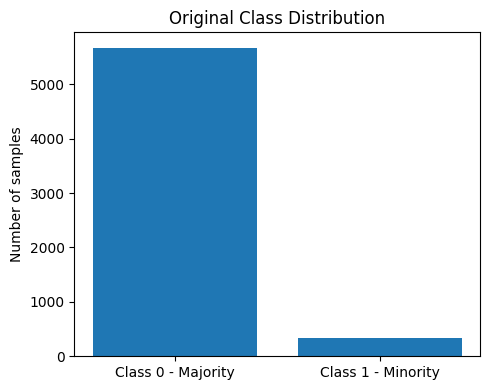

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_original_class_distribution.png


0    5671
1     329
Name: count, dtype: int64

In [5]:
class_counts = pd.Series(y).value_counts().sort_index()

plt.figure(figsize=(5, 4))
plt.bar(["Class 0 - Majority", "Class 1 - Minority"], class_counts.values)
plt.title("Original Class Distribution")
plt.ylabel("Number of samples")
save_plot("day03_original_class_distribution.png")

display(class_counts)

# 2. Train/Test Split

Important:
We use `stratify=y` so that train and test keep the same class ratio.

This is very important for imbalanced data.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({0: 3970, 1: 230})
Test distribution: Counter({0: 1701, 1: 99})


# 3. Baseline model

We train a Logistic Regression without any special handling for imbalanced data.

This shows why accuracy can be misleading.

In [7]:
baseline_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = evaluate_classifier(
    "Baseline Logistic Regression",
    y_test,
    y_pred_baseline,
    y_prob_baseline
)

display(pd.DataFrame([baseline_metrics]))

print(classification_report(y_test, y_pred_baseline, zero_division=0))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Baseline Logistic Regression,0.946111,0.75,0.030303,0.058252,0.721382


              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1701
           1       0.75      0.03      0.06        99

    accuracy                           0.95      1800
   macro avg       0.85      0.51      0.52      1800
weighted avg       0.94      0.95      0.92      1800



[[1700    1]
 [  96    3]]


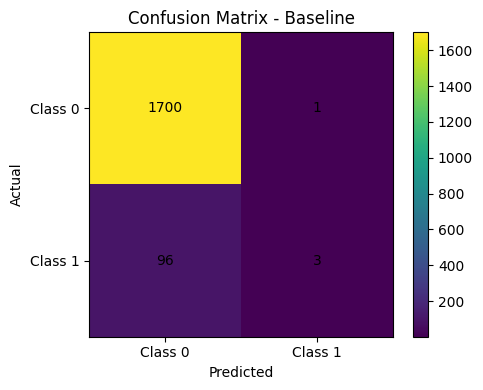

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_confusion_matrix_baseline.png


In [8]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
print(cm_baseline)

plot_confusion_matrix(
    cm_baseline,
    "Confusion Matrix - Baseline",
    "day03_confusion_matrix_baseline.png"
)

# Important interpretation

Accuracy can look high because the majority class dominates.

Example:
If 95% of the data is class 0, a model can predict class 0 most of the time and still get high accuracy.

For imbalanced data, we need:

- Precision
- Recall
- F1-score
- ROC AUC
- Confusion Matrix

# 4. Class Weight / Cost-Sensitive Learning

Now we tell the model that minority class errors are more important.

In scikit-learn:

`class_weight="balanced"`

This does not change the data.
It changes the loss/cost function of the algorithm.

In [9]:
weighted_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

weighted_model.fit(X_train, y_train)

y_pred_weighted = weighted_model.predict(X_test)
y_prob_weighted = weighted_model.predict_proba(X_test)[:, 1]

weighted_metrics = evaluate_classifier(
    "Weighted Logistic Regression",
    y_test,
    y_pred_weighted,
    y_prob_weighted
)

display(pd.DataFrame([weighted_metrics]))

print(classification_report(y_test, y_pred_weighted, zero_division=0))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Weighted Logistic Regression,0.658889,0.100775,0.656566,0.174731,0.725212


              precision    recall  f1-score   support

           0       0.97      0.66      0.79      1701
           1       0.10      0.66      0.17        99

    accuracy                           0.66      1800
   macro avg       0.54      0.66      0.48      1800
weighted avg       0.92      0.66      0.75      1800



[[1121  580]
 [  34   65]]


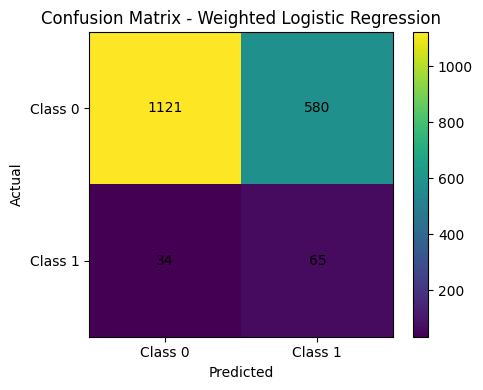

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_confusion_matrix_weighted.png


In [10]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)
print(cm_weighted)

plot_confusion_matrix(
    cm_weighted,
    "Confusion Matrix - Weighted Logistic Regression",
    "day03_confusion_matrix_weighted.png"
)

# 5. Random Undersampling

Random undersampling reduces the majority class.

Advantage:
- Makes the dataset balanced

Risk:
- Information loss, because many majority samples are removed

In [11]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Before undersampling:", Counter(y_train))
print("After undersampling:", Counter(y_train_under))

Before undersampling: Counter({0: 3970, 1: 230})
After undersampling: Counter({0: 230, 1: 230})


In [12]:
under_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

under_model.fit(X_train_under, y_train_under)

y_pred_under = under_model.predict(X_test)
y_prob_under = under_model.predict_proba(X_test)[:, 1]

under_metrics = evaluate_classifier(
    "Random Undersampling + Logistic Regression",
    y_test,
    y_pred_under,
    y_prob_under
)

display(pd.DataFrame([under_metrics]))

print(classification_report(y_test, y_pred_under, zero_division=0))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Undersampling + Logistic Regression,0.622222,0.092567,0.666667,0.162562,0.69561


              precision    recall  f1-score   support

           0       0.97      0.62      0.76      1701
           1       0.09      0.67      0.16        99

    accuracy                           0.62      1800
   macro avg       0.53      0.64      0.46      1800
weighted avg       0.92      0.62      0.72      1800



# 6. Random Oversampling

Random oversampling increases the minority class by duplicating minority examples.

Advantage:
- No majority data is removed

Risk:
- Overfitting, because duplicated samples can be memorized by the model

In [13]:
ros = RandomOverSampler(random_state=42)
X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before oversampling:", Counter(y_train))
print("After oversampling:", Counter(y_train_over))

Before oversampling: Counter({0: 3970, 1: 230})
After oversampling: Counter({0: 3970, 1: 3970})


In [14]:
over_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

over_model.fit(X_train_over, y_train_over)

y_pred_over = over_model.predict(X_test)
y_prob_over = over_model.predict_proba(X_test)[:, 1]

over_metrics = evaluate_classifier(
    "Random Oversampling + Logistic Regression",
    y_test,
    y_pred_over,
    y_prob_over
)

display(pd.DataFrame([over_metrics]))

print(classification_report(y_test, y_pred_over, zero_division=0))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Random Oversampling + Logistic Regression,0.652778,0.099085,0.656566,0.172185,0.721079


              precision    recall  f1-score   support

           0       0.97      0.65      0.78      1701
           1       0.10      0.66      0.17        99

    accuracy                           0.65      1800
   macro avg       0.53      0.65      0.48      1800
weighted avg       0.92      0.65      0.75      1800



# 7. SMOTE

SMOTE creates synthetic minority samples instead of simply duplicating existing minority samples.

It creates new points between minority class samples and their nearest neighbors.

This often works better than random oversampling.

In [15]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", Counter(y_train))
print("After SMOTE:", Counter(y_train_smote))

Before SMOTE: Counter({0: 3970, 1: 230})
After SMOTE: Counter({0: 3970, 1: 3970})


  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\esmae\.conda\envs\py311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [16]:
smote_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test)
y_prob_smote = smote_model.predict_proba(X_test)[:, 1]

smote_metrics = evaluate_classifier(
    "SMOTE + Logistic Regression",
    y_test,
    y_pred_smote,
    y_prob_smote
)

display(pd.DataFrame([smote_metrics]))

print(classification_report(y_test, y_pred_smote, zero_division=0))

,Model,Accuracy,Precision,Recall,F1,AUC
0,SMOTE + Logistic Regression,0.657778,0.104135,0.686869,0.180851,0.717385


              precision    recall  f1-score   support

           0       0.97      0.66      0.78      1701
           1       0.10      0.69      0.18        99

    accuracy                           0.66      1800
   macro avg       0.54      0.67      0.48      1800
weighted avg       0.93      0.66      0.75      1800



[[1116  585]
 [  31   68]]


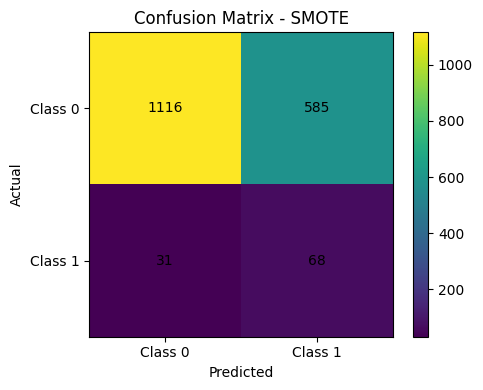

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_confusion_matrix_smote.png


In [17]:
cm_smote = confusion_matrix(y_test, y_pred_smote)
print(cm_smote)

plot_confusion_matrix(
    cm_smote,
    "Confusion Matrix - SMOTE",
    "day03_confusion_matrix_smote.png"
)

# 8. Compare all methods

We compare:

1. Baseline Logistic Regression
2. Weighted Logistic Regression
3. Random Undersampling
4. Random Oversampling
5. SMOTE

For imbalanced data, focus especially on Recall, F1, and AUC.

In [18]:
all_results = pd.DataFrame([
    baseline_metrics,
    weighted_metrics,
    under_metrics,
    over_metrics,
    smote_metrics
])

all_results = all_results.sort_values("F1", ascending=False)

display(all_results)

all_results.to_csv(OUTPUT_DIR / "day03_model_comparison.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,AUC
4,SMOTE + Logistic Regression,0.657778,0.104135,0.686869,0.180851,0.717385
1,Weighted Logistic Regression,0.658889,0.100775,0.656566,0.174731,0.725212
3,Random Oversampling + Logistic Regression,0.652778,0.099085,0.656566,0.172185,0.721079
2,Random Undersampling + Logistic Regression,0.622222,0.092567,0.666667,0.162562,0.695610
0,Baseline Logistic Regression,0.946111,0.750000,0.030303,0.058252,0.721382


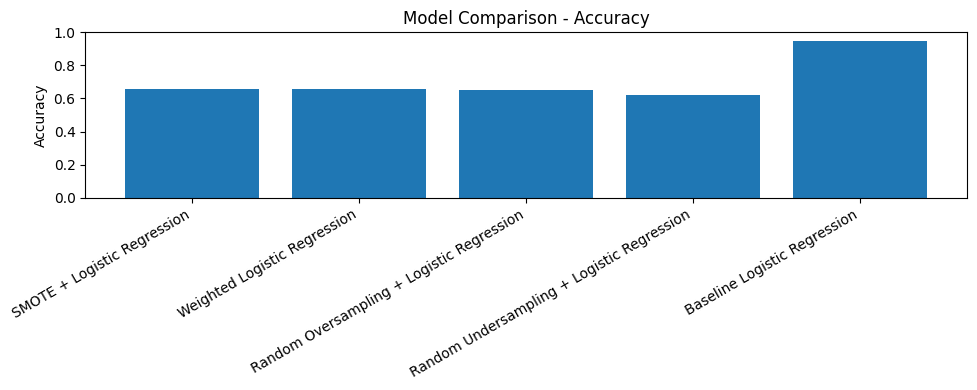

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_model_comparison_Accuracy.png


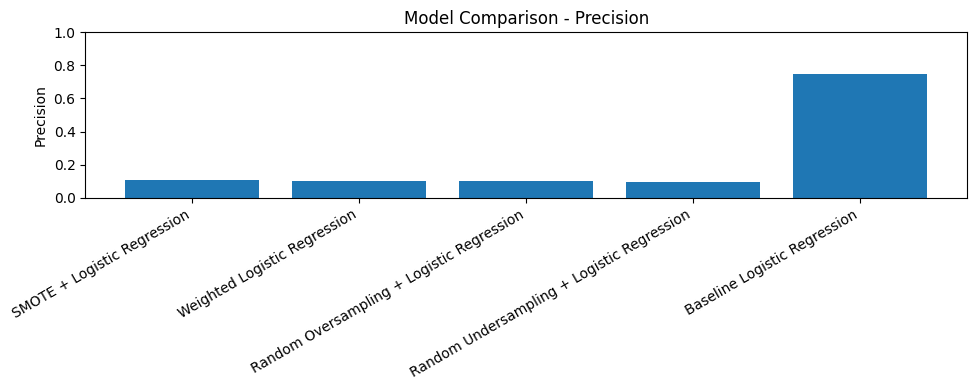

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_model_comparison_Precision.png


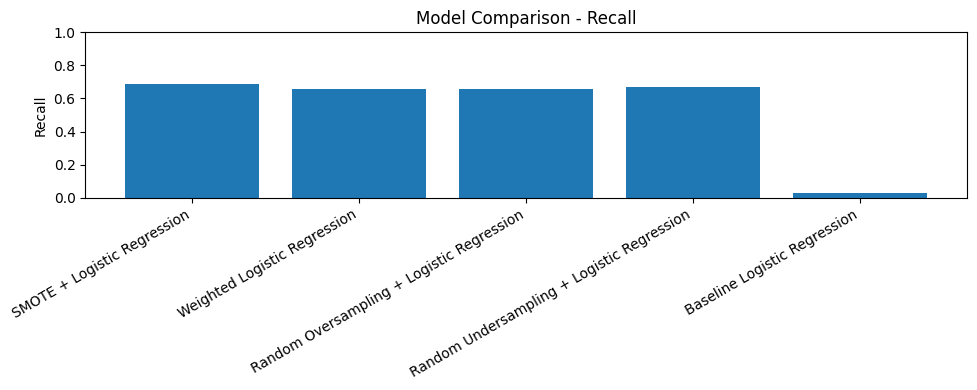

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_model_comparison_Recall.png


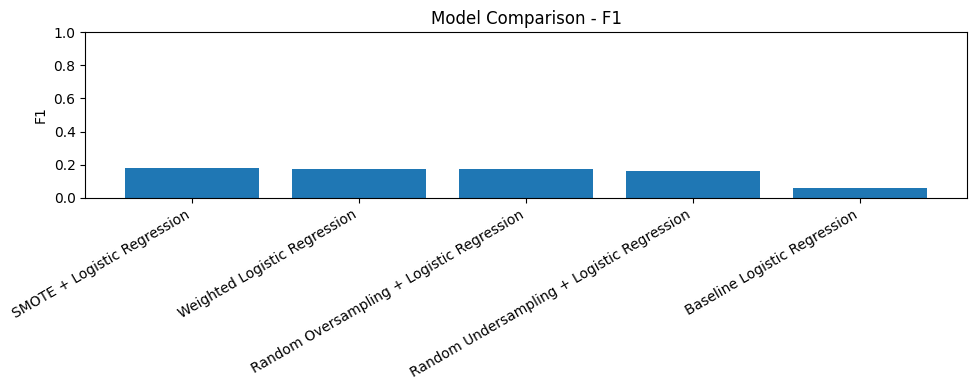

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_model_comparison_F1.png


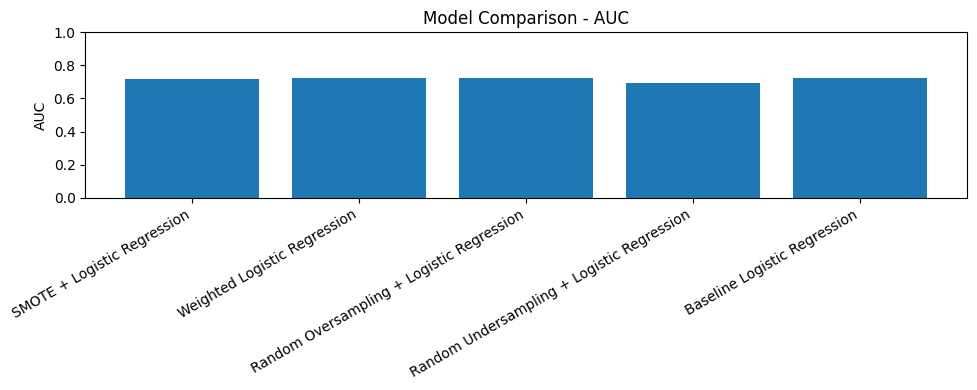

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_model_comparison_AUC.png


In [19]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

for metric in metrics_to_plot:
    plt.figure(figsize=(10, 4))
    plt.bar(all_results["Model"], all_results[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.ylim(0, 1)
    plt.xticks(rotation=30, ha="right")
    save_plot(f"day03_model_comparison_{metric}.png")

# 9. ROC Curve and AUC

ROC Curve shows the relation between:

- TPR / Recall
- FPR

AUC summarizes the model performance across all thresholds.

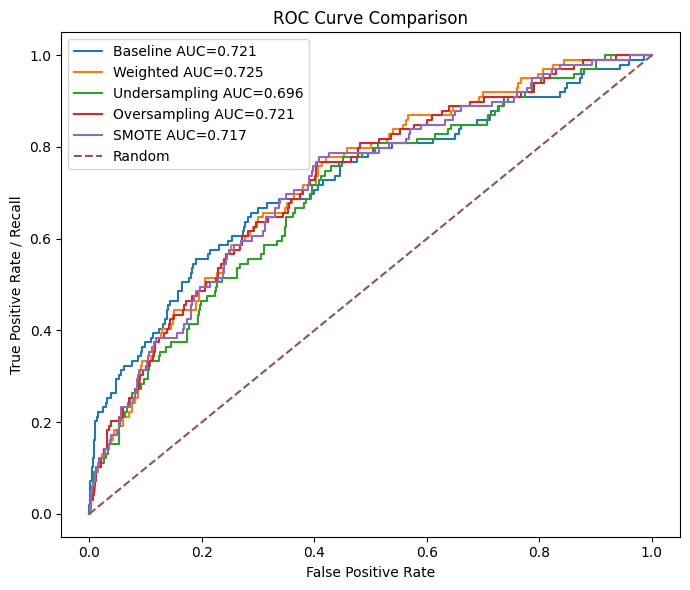

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_roc_curve_comparison.png


In [20]:
roc_data = {
    "Baseline": y_prob_baseline,
    "Weighted": y_prob_weighted,
    "Undersampling": y_prob_under,
    "Oversampling": y_prob_over,
    "SMOTE": y_prob_smote
}

plt.figure(figsize=(7, 6))

for name, y_prob in roc_data.items():
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    auc_value = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc_value:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend()
save_plot("day03_roc_curve_comparison.png")

# 10. Manual Threshold Analysis

A classifier often outputs probabilities.

Example:
- probability >= 0.5 => class 1
- probability < 0.5 => class 0

If we lower the threshold, recall usually increases.
But false positives usually increase too.

This is exactly the logic behind ROC curves.

In [21]:
def threshold_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    return {
        "Threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "TPR_Recall": tpr,
        "FPR": fpr,
        "Precision": precision,
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_table = pd.DataFrame([
    threshold_metrics(y_test, y_prob_smote, threshold)
    for threshold in thresholds
])

display(threshold_table)

threshold_table.to_csv(OUTPUT_DIR / "day03_threshold_analysis_smote.csv", index=False)

,Threshold,TP,FP,FN,TN,TPR_Recall,FPR,Precision,F1
0,0.1,98,1617,1,84,0.989899,0.950617,0.057143,0.108049
1,0.2,95,1400,4,301,0.959596,0.823045,0.063545,0.119197
2,0.3,88,1140,11,561,0.888889,0.670194,0.071661,0.132630
3,0.4,78,853,21,848,0.787879,0.501470,0.083781,0.151456
4,0.5,68,585,31,1116,0.686869,0.343915,0.104135,0.180851
5,0.6,49,351,50,1350,0.494949,0.206349,0.122500,0.196393
6,0.7,35,184,64,1517,0.353535,0.108172,0.159817,0.220126
7,0.8,16,65,83,1636,0.161616,0.038213,0.197531,0.177778
8,0.9,5,6,94,1695,0.050505,0.003527,0.454545,0.090909


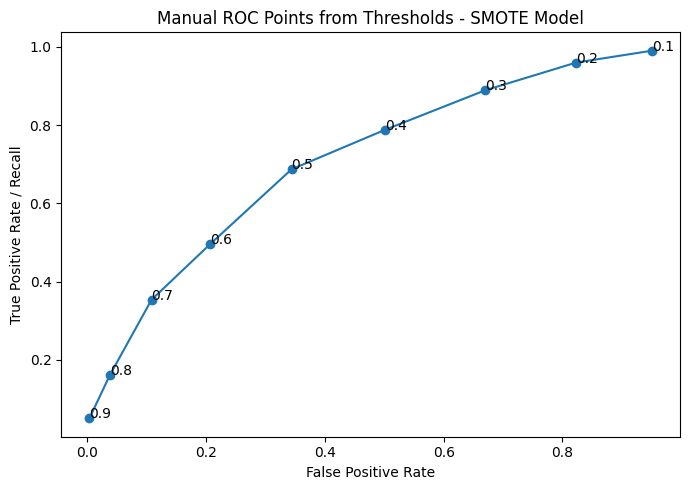

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_manual_threshold_roc_points.png


In [22]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_table["FPR"], threshold_table["TPR_Recall"], marker="o")

for _, row in threshold_table.iterrows():
    plt.text(row["FPR"], row["TPR_Recall"], str(row["Threshold"]))

plt.title("Manual ROC Points from Thresholds - SMOTE Model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
save_plot("day03_manual_threshold_roc_points.png")

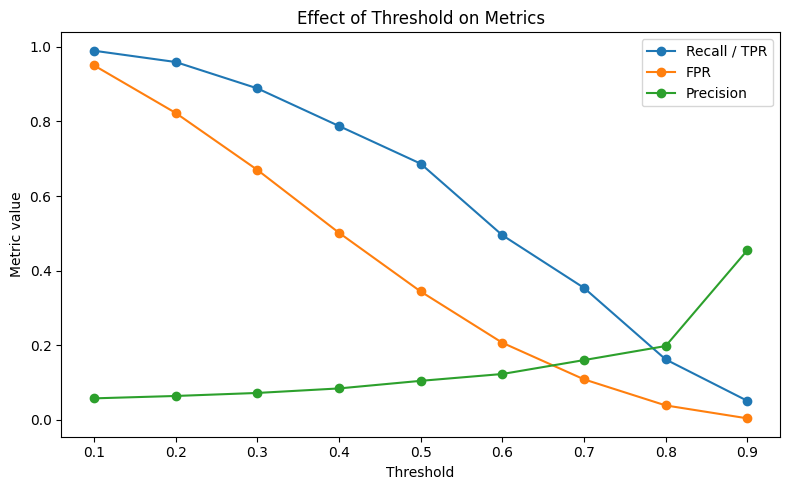

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\03-imbalanced-learning-techniques\output\Experte\day03_threshold_effect_on_metrics.png


In [23]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_table["Threshold"], threshold_table["TPR_Recall"], marker="o", label="Recall / TPR")
plt.plot(threshold_table["Threshold"], threshold_table["FPR"], marker="o", label="FPR")
plt.plot(threshold_table["Threshold"], threshold_table["Precision"], marker="o", label="Precision")
plt.title("Effect of Threshold on Metrics")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
save_plot("day03_threshold_effect_on_metrics.png")

# Day 3 Summary

Key points:

- Imbalanced data means one class appears much more often than another.
- Accuracy can be misleading for imbalanced classification.
- Confusion Matrix shows TP, FP, FN, TN.
- Recall is important when missing the positive class is dangerous.
- Precision is important when false alarms are costly.
- F1 balances Precision and Recall.
- ROC curve shows TPR vs FPR across thresholds.
- AUC summarizes overall model performance.
- Random undersampling can lose information.
- Random oversampling can cause overfitting.
- SMOTE creates synthetic minority examples.
- Class weighting changes the loss function without changing the data.